## Initial Set Up

In [1]:
import pandas as pd                                        
df = pd.read_csv(r"F:\Agentic_Hackathon\cfpb_data\complaints.csv")

In [2]:
# Drop rows where 'Consumer complaint narrative' is null   
df = df.dropna(subset=['Consumer complaint narrative'])    

In [3]:
# Convert 'Date received' to datetime
df['Date received'] = pd.to_datetime(df['Date received'])  

# Filter for JPMorgan Chase
df_jpm = df[df['Company'] == 'JPMORGAN CHASE & CO.']       

# Filter for date range 2024–2026
df_jpm = df_jpm[
    (df_jpm['Date received'] >= '2024-01-01') &
    (df_jpm['Date received'] <= '2026-12-31')
]

In [4]:
# Reset index
df_jpm = df_jpm.reset_index(drop=True)

print(f"Total records: {len(df_jpm):,}")
print(f"Date range: {df_jpm['Date received'].min()} →  {df_jpm['Date received'].max()}")
print(f"\nShape: {df_jpm.shape}")

Total records: 22,465
Date range: 2024-01-01 00:00:00 →  2026-02-02 00:00:00

Shape: (22465, 18)


In [5]:
df_jpm.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2024-02-01,"Money transfer, virtual currency, or money ser...",Virtual currency,Fraud or scam,NaN,"XXXX XXXX2023, I fell victim to two multi-laye...",NaN,JPMORGAN CHASE & CO.,FL,32043,Older American,Consent provided,Web,2024-02-02,Closed with explanation,Yes,NaN,8266742
1,2024-01-08,"Money transfer, virtual currency, or money ser...",Domestic (US) money transfer,Other transaction problem,NaN,"On XXXX XXXX a friend of mine from Soccer, XXX...",NaN,JPMORGAN CHASE & CO.,FL,33139,NaN,Consent provided,Web,2024-01-08,Closed with explanation,Yes,NaN,8123972
2,2024-03-04,Checking or savings account,Checking account,Managing an account,Deposits and withdrawals,Chase Bank informed me last XX/XX/XXXX about a...,NaN,JPMORGAN CHASE & CO.,CA,91343,Older American,Consent provided,Web,2024-03-04,Closed with explanation,Yes,NaN,8476358
3,2025-05-13,Checking or savings account,Checking account,Managing an account,Problem using a debit or ATM card,A unauthorized purchase and money transfer fro...,NaN,JPMORGAN CHASE & CO.,TX,79938,NaN,Consent provided,Web,2025-05-13,Closed with explanation,Yes,NaN,13457424
4,2025-01-22,Credit card,General-purpose credit card or charge card,"Advertising and marketing, including promotion...",Didn't receive advertised or promotional terms,I signed up for a XXXXXX/XX/XXXXXXXX with Chas...,NaN,JPMORGAN CHASE & CO.,SC,29412,NaN,Consent provided,Web,2025-01-22,Closed with monetary relief,Yes,NaN,11737202


In [6]:
df_jpm.to_csv("JP_Morgan_file.csv", index = False)

In [7]:
import pandas as pd

# 1. Load the dataset
file_path = r'f:\Agentic_Hackathon\tests\JP_Morgan_file.csv'
df = pd.read_csv(file_path)

# 2. Restrict analytics strictly to JP Morgan (JPMORGAN CHASE & CO.)
df_jpm = df[df['Company'] == 'JPMORGAN CHASE & CO.']

# ---------------------------------------------------------
# A. TOTAL ANALYTICS
# ---------------------------------------------------------
total_complaints = len(df_jpm)
unique_products = df_jpm['Product'].nunique()
unique_sub_products = df_jpm['Sub-product'].nunique()
unique_issues = df_jpm['Issue'].nunique()
unique_sub_issues = df_jpm['Sub-issue'].nunique()

print("========== OVERALL JP MORGAN ANALYTICS ==========")
print(f"Total Complaints:    {total_complaints}")
print(f"Unique Products:     {unique_products}")
print(f"Unique Sub-products: {unique_sub_products}")
print(f"Unique Issues:       {unique_issues}")
print(f"Unique Sub-issues:   {unique_sub_issues}")
print("=================================================\n")

# ---------------------------------------------------------
# B. PRODUCT-WISE SEGREGATION
# ---------------------------------------------------------
print("--> Top Products by Complaint Volume:")
product_segregation = df_jpm['Product'].value_counts().reset_index()
product_segregation.columns = ['Product', 'Total Complaints']
display(product_segregation) # Use display() for pretty Jupyter rendering

# ---------------------------------------------------------
# C. SUB-PRODUCT-WISE SEGREGATION
# ---------------------------------------------------------
print("--> Product & Sub-Product Breakdown:")
sub_product_segregation = df_jpm.groupby(['Product'])['Sub-product'].value_counts().reset_index(name='Total Complaints')
display(sub_product_segregation)

# ---------------------------------------------------------
# D. ISSUE-WISE SEGREGATION
# ---------------------------------------------------------
print("--> Product, Sub-Product, and Issue Breakdown:")
issue_segregation = df_jpm.groupby(['Product', 'Sub-product'])['Issue'].value_counts().reset_index(name='Total Complaints')
display(issue_segregation.sort_values(by='Total Complaints', ascending=False).head(20)) # Showing top 20 issues

# ---------------------------------------------------------
# E. SUB-ISSUE-WISE SEGREGATION
# ---------------------------------------------------------
print("--> Complete Hierarchical Segregation (Product -> Sub-Product -> Issue -> Sub-Issue):")
# Dropping rows where Sub-issue might be NaN for cleaner hierarchical views
df_hierarchical = df_jpm.dropna(subset=['Sub-issue'])
sub_issue_segregation = df_hierarchical.groupby(
    ['Product', 'Sub-product', 'Issue', 'Sub-issue']
).size().reset_index(name='Total Complaints')

# Sort to show the highest volume deep-drill issues first
sub_issue_segregation = sub_issue_segregation.sort_values(by='Total Complaints', ascending=False)
display(sub_issue_segregation.head(30)) # Showing top 30 granular sub-issues


========== OVERALL JP MORGAN ANALYTICS ==========
Total Complaints:    22465
Unique Products:     11
Unique Sub-products: 50
Unique Issues:       76
Unique Sub-issues:   176

--> Top Products by Complaint Volume:


,Product,Total Complaints
0,Checking or savings account,9299
1,Credit card,6384
2,Credit reporting or other personal consumer re...,2987
3,"Money transfer, virtual currency, or money ser...",2028
4,Debt collection,771
5,Mortgage,519
6,Vehicle loan or lease,377
7,Debt or credit management,36
8,"Payday loan, title loan, personal loan, or adv...",35
9,Prepaid card,25


--> Product & Sub-Product Breakdown:


,Product,Sub-product,Total Complaints
0,Checking or savings account,Checking account,8115
1,Checking or savings account,Other banking product or service,611
2,Checking or savings account,Savings account,474
3,Checking or savings account,CD (Certificate of Deposit),99
4,Credit card,General-purpose credit card or charge card,6315
5,Credit card,Store credit card,69
6,Credit reporting or other personal consumer re...,Credit reporting,2922
7,Credit reporting or other personal consumer re...,Other personal consumer report,65
8,Debt collection,Credit card debt,486
9,Debt collection,I do not know,191


--> Product, Sub-Product, and Issue Breakdown:


,Product,Sub-product,Issue,Total Complaints
4,Checking or savings account,Checking account,Managing an account,4295
29,Credit card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,1988
5,Checking or savings account,Checking account,Closing an account,1483
6,Checking or savings account,Checking account,Problem with a lender or other company chargin...,1248
55,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,1213
30,Credit card,General-purpose credit card or charge card,"Other features, terms, or problems",1199
56,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,1115
31,Credit card,General-purpose credit card or charge card,Getting a credit card,712
32,Credit card,General-purpose credit card or charge card,Closing your account,550
33,Credit card,General-purpose credit card or charge card,"Advertising and marketing, including promotion...",536


--> Complete Hierarchical Segregation (Product -> Sub-Product -> Issue -> Sub-Issue):


,Product,Sub-product,Issue,Sub-issue,Total Complaints
28,Checking or savings account,Checking account,Managing an account,Deposits and withdrawals,1705
143,Credit card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute ...,1453
48,Checking or savings account,Checking account,Problem with a lender or other company chargin...,Transaction was not authorized,1051
33,Checking or savings account,Checking account,Managing an account,Problem using a debit or ATM card,993
13,Checking or savings account,Checking account,Closing an account,Company closed your account,794
15,Checking or savings account,Checking account,Closing an account,Funds not received from closed account,597
181,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,564
178,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Credit inquiries on your report that you don't...,534
104,Credit card,General-purpose credit card or charge card,Closing your account,Company closed your account,491
30,Checking or savings account,Checking account,Managing an account,Funds not handled or disbursed as instructed,488


### Visualizing Products and Sub Products with counts

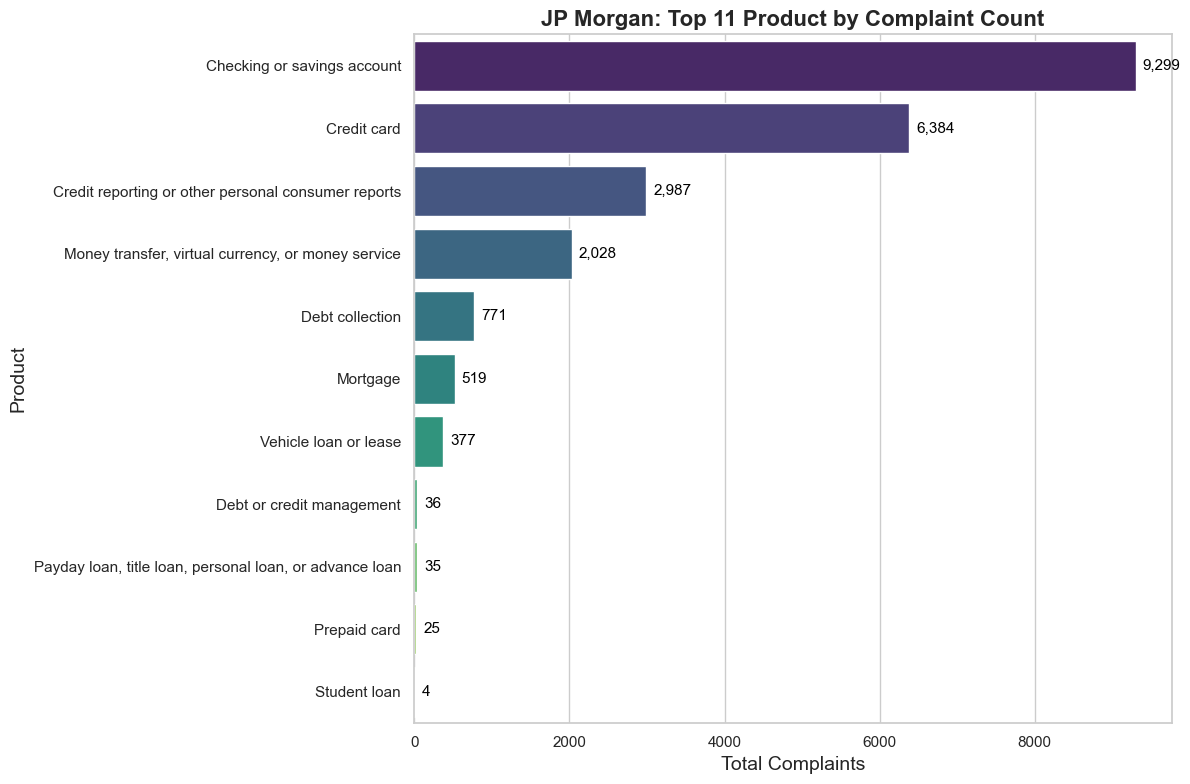

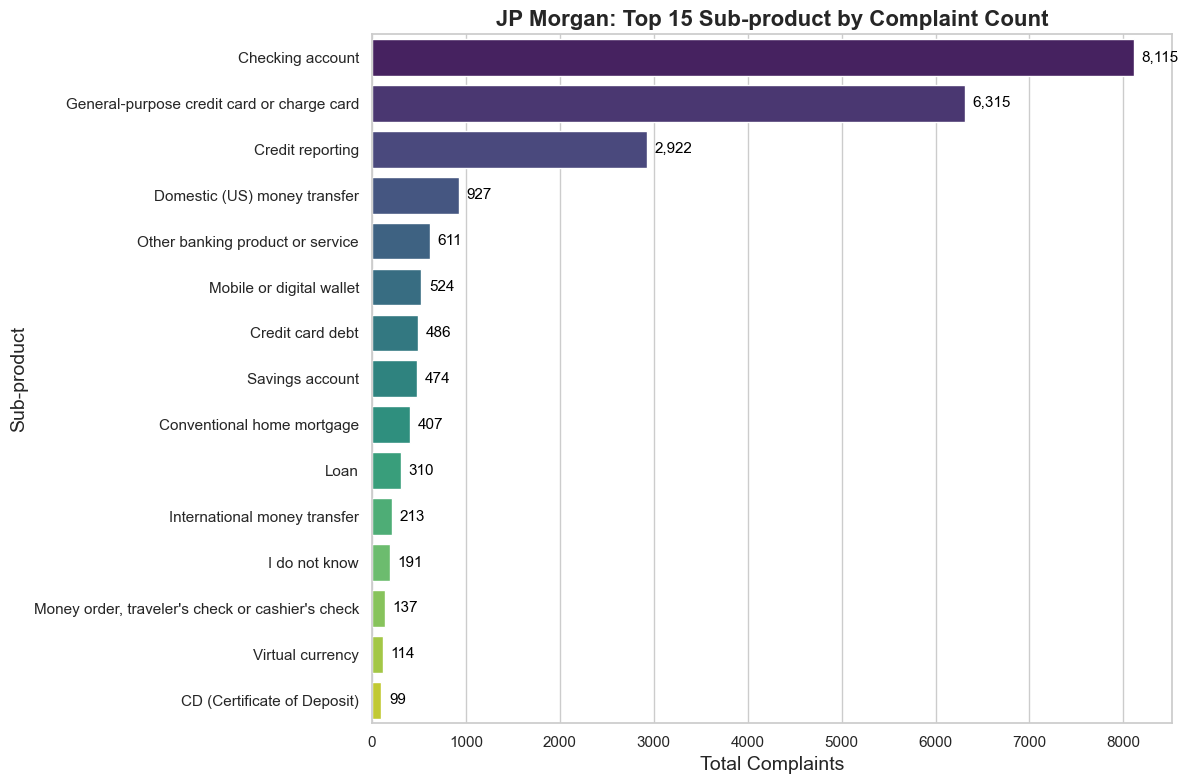

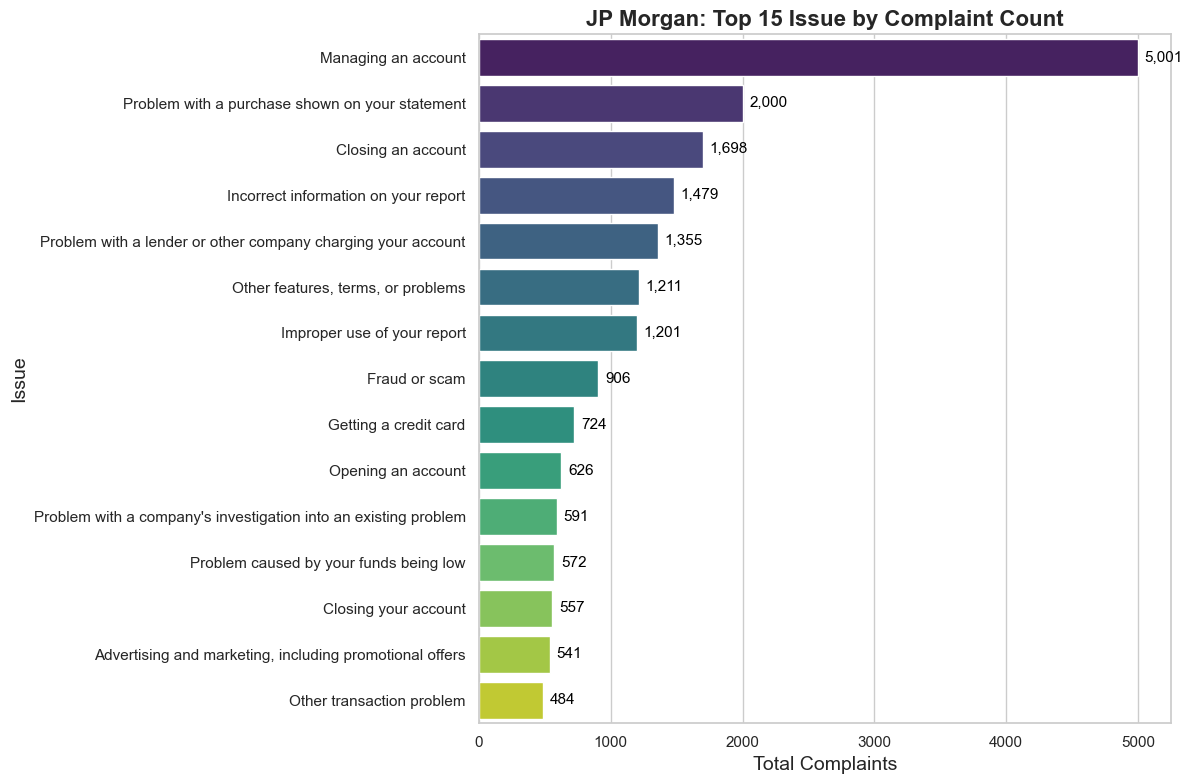

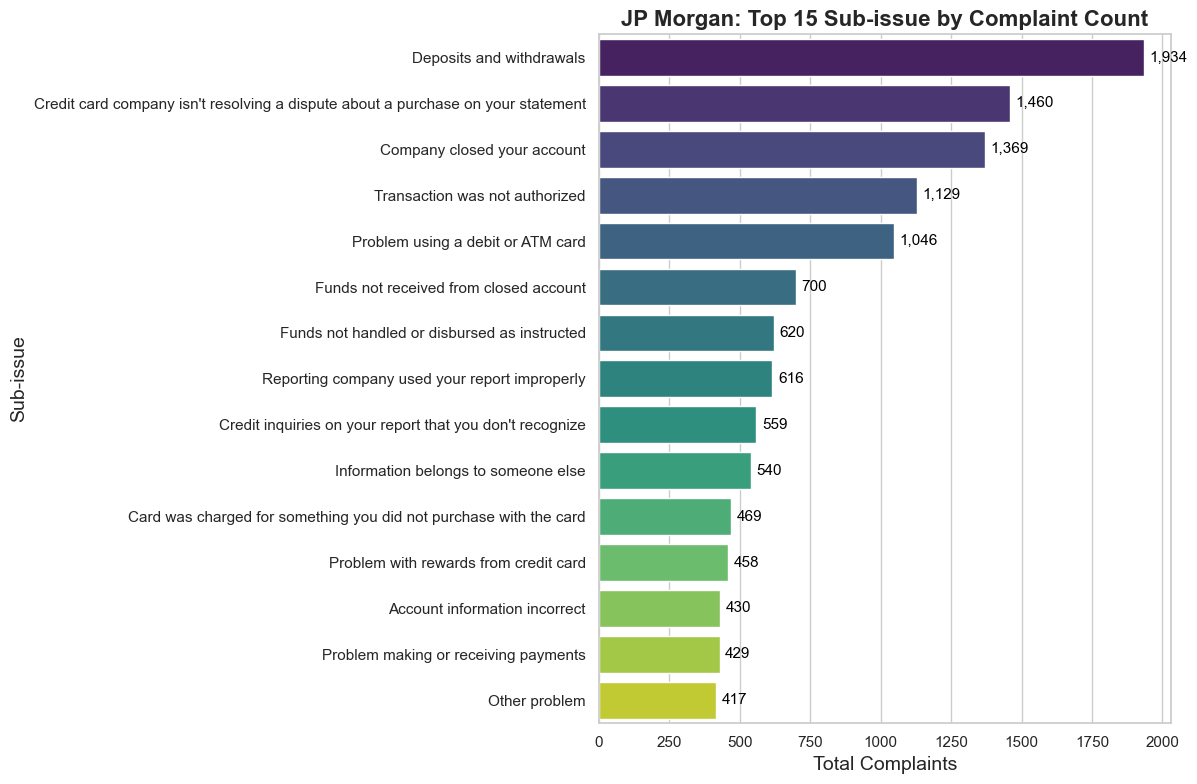

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style for nicer charts
sns.set_theme(style="whitegrid")

def plot_top_categories(df, column_name, top_n=15, title_prefix="JP Morgan:"):
    """
    Plots a horizontal bar chart for the top N categories of a given column in decreasing order.
    """
    # Count frequencies, sort in descending order, and take top N
    counts = df[column_name].value_counts().head(top_n)
    
    # Initialize the matplotlib figure
    plt.figure(figsize=(12, 8))
    
    # Plot using seaborn
    ax = sns.barplot(x=counts.values, y=counts.index, hue=counts.index, palette="viridis", legend=False)
    
    # Add titles and labels
    plt.title(f"{title_prefix} Top {len(counts)} {column_name} by Complaint Count", fontsize=16, fontweight='bold')
    plt.xlabel("Total Complaints", fontsize=14)
    plt.ylabel(column_name, fontsize=14)
    
    # Add the exact number next to each bar
    for i, v in enumerate(counts.values):
        ax.text(v + (counts.values.max() * 0.01), i, f"{v:,}", color='black', va='center', fontsize=11)
        
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# GENERATE THE PLOTS
# ---------------------------------------------------------

# 1. Product Plot
plot_top_categories(df_jpm, 'Product', top_n=15)

# 2. Sub-product Plot
plot_top_categories(df_jpm, 'Sub-product', top_n=15)

# 3. Issue Plot
plot_top_categories(df_jpm, 'Issue', top_n=15)

# 4. Sub-issue Plot
plot_top_categories(df_jpm, 'Sub-issue', top_n=15)


### Getting Products, Sub Products, Issues and Sub-issues with counts

In [15]:
import pandas as pd

# ---------------------------------------------------------
# 1. ALL PRODUCTS -> SUB-PRODUCTS LISTING
# ---------------------------------------------------------
# Group data for Products and Sub-products
prod_subprod_counts = df_jpm.groupby(['Product', 'Sub-product']).size().reset_index(name='Count')
prod_subprod_counts = prod_subprod_counts.sort_values(by=['Product', 'Count'], ascending=[True, False])
overall_product = df_jpm['Product'].value_counts()

print("========== ALL PRODUCTS & SUB-PRODUCTS ==========\n")
for product_name in overall_product.index:
    total_prod_count = overall_product[product_name]
    print(f"■ PRODUCT: {product_name} (Total: {total_prod_count})")
    
    sub_df = prod_subprod_counts[prod_subprod_counts['Product'] == product_name]
    
    if sub_df.empty:
        print("    ↳ (No Sub-products specified)")
    else:
        for _, row in sub_df.iterrows():
            print(f"    ↳ SUB-PRODUCT: {row['Sub-product']} (Count: {row['Count']})")
    
    print("-" * 80)


print("\n\n")


# ---------------------------------------------------------
# 2. ALL ISSUES -> SUB-ISSUES LISTING
# ---------------------------------------------------------
# Group data for Issues and Sub-issues
issue_subissue_counts = df_jpm.groupby(['Issue', 'Sub-issue']).size().reset_index(name='Count')
issue_subissue_counts = issue_subissue_counts.sort_values(by=['Issue', 'Count'], ascending=[True, False])
overall_issue = df_jpm['Issue'].value_counts()

print("========== ALL ISSUES & SUB-ISSUES ==========\n")
for issue_name in overall_issue.index:
    total_issue_count = overall_issue[issue_name]
    print(f"■ ISSUE: {issue_name} (Total: {total_issue_count})")
    
    sub_df = issue_subissue_counts[issue_subissue_counts['Issue'] == issue_name]
    
    if sub_df.empty:
        print("    ↳ (No Sub-issues specified)")
    else:
        for _, row in sub_df.iterrows():
            print(f"    ↳ SUB-ISSUE: {row['Sub-issue']} (Count: {row['Count']})")
            
    print("-" * 80)


========== ALL PRODUCTS & SUB-PRODUCTS ==========

■ PRODUCT: Checking or savings account (Total: 9299)
    ↳ SUB-PRODUCT: Checking account (Count: 8115)
    ↳ SUB-PRODUCT: Other banking product or service (Count: 611)
    ↳ SUB-PRODUCT: Savings account (Count: 474)
    ↳ SUB-PRODUCT: CD (Certificate of Deposit) (Count: 99)
--------------------------------------------------------------------------------
■ PRODUCT: Credit card (Total: 6384)
    ↳ SUB-PRODUCT: General-purpose credit card or charge card (Count: 6315)
    ↳ SUB-PRODUCT: Store credit card (Count: 69)
--------------------------------------------------------------------------------
■ PRODUCT: Credit reporting or other personal consumer reports (Total: 2987)
    ↳ SUB-PRODUCT: Credit reporting (Count: 2922)
    ↳ SUB-PRODUCT: Other personal consumer report (Count: 65)
--------------------------------------------------------------------------------
■ PRODUCT: Money transfer, virtual currency, or money service (Total: 2028)
    

In [16]:
# 1. Calculate the total counts for each Product
product_counts = df_jpm['Product'].value_counts()

# 2. Identify strictly the products that have more than 100 complaints
products_over_100 = product_counts[product_counts > 100].index

# 3. Create the new dataframe by filtering the original data
df_jpm_filtered = df_jpm[df_jpm['Product'].isin(products_over_100)].copy()

# 4. Save the dataframe to a new CSV file in your tests folder
output_csv_path = r'f:\Agentic_Hackathon\tests\JPM_Filtered_Products_Over_100.csv'
df_jpm_filtered.to_csv(output_csv_path, index=False)

# --- Verification ---
print(f"Original JP Morgan Data Rows: {len(df_jpm)}")
print(f"Filtered Data Rows:           {len(df_jpm_filtered)}")
print(f"\nNew Dataframe successfully saved to: {output_csv_path}\n")

print("Remaining Products and their counts:")
display(df_jpm_filtered['Product'].value_counts())


Original JP Morgan Data Rows: 22465
Filtered Data Rows:           22365

New Dataframe successfully saved to: f:\Agentic_Hackathon\tests\JPM_Filtered_Products_Over_100.csv

Remaining Products and their counts:


Product
Checking or savings account                            9299
Credit card                                            6384
Credit reporting or other personal consumer reports    2987
Money transfer, virtual currency, or money service     2028
Debt collection                                         771
Mortgage                                                519
Vehicle loan or lease                                   377
Name: count, dtype: int64

In [17]:
# --- Code Block 1: Product & Sub-Product Analysis on Filtered Data ---

total_filtered_complaints = len(df_jpm_filtered)
print(f"TOTAL COMPLAINTS IN FILTERED DATASET: {total_filtered_complaints}\n")

print("========== PRODUCT LEVEL ANALYSIS ==========")
product_counts = df_jpm_filtered['Product'].value_counts()

for product_name, p_count in product_counts.items():
    # Calculate percentage relative to the whole dataset
    p_percent = (p_count / total_filtered_complaints) * 100
    
    print(f"■ PRODUCT: {product_name}")
    print(f"  Total: {p_count} | {p_percent:.2f}% of overall dataset")
    
    # Sub-product Level Analysis strictly within this Product
    sub_product_counts = df_jpm_filtered[df_jpm_filtered['Product'] == product_name]['Sub-product'].value_counts()
    
    if sub_product_counts.empty:
        print("    ↳ (No Sub-products specified)")
    else:
        for sub_name, s_count in sub_product_counts.items():
            # Calculate percentage relative to its parent product
            s_percent = (s_count / p_count) * 100
            print(f"    ↳ SUB-PRODUCT: {sub_name}  -->  {s_count} ({s_percent:.1f}%)")
            
    print("-" * 70)


TOTAL COMPLAINTS IN FILTERED DATASET: 22365

========== PRODUCT LEVEL ANALYSIS ==========
■ PRODUCT: Checking or savings account
  Total: 9299 | 41.58% of overall dataset
    ↳ SUB-PRODUCT: Checking account  -->  8115 (87.3%)
    ↳ SUB-PRODUCT: Other banking product or service  -->  611 (6.6%)
    ↳ SUB-PRODUCT: Savings account  -->  474 (5.1%)
    ↳ SUB-PRODUCT: CD (Certificate of Deposit)  -->  99 (1.1%)
----------------------------------------------------------------------
■ PRODUCT: Credit card
  Total: 6384 | 28.54% of overall dataset
    ↳ SUB-PRODUCT: General-purpose credit card or charge card  -->  6315 (98.9%)
    ↳ SUB-PRODUCT: Store credit card  -->  69 (1.1%)
----------------------------------------------------------------------
■ PRODUCT: Credit reporting or other personal consumer reports
  Total: 2987 | 13.36% of overall dataset
    ↳ SUB-PRODUCT: Credit reporting  -->  2922 (97.8%)
    ↳ SUB-PRODUCT: Other personal consumer report  -->  65 (2.2%)
-----------------------

In [18]:
# --- Code Block 2: Issue & Sub-Issue Analysis on Filtered Data ---

total_filtered_complaints = len(df_jpm_filtered)

print("========== ISSUE LEVEL ANALYSIS ==========")
issue_counts = df_jpm_filtered['Issue'].value_counts()

print(f"Showing Top 20 out of {len(issue_counts)} unique issues...\n")

for issue_name, i_count in issue_counts.head(20).items():
    # Calculate percentage relative to the whole dataset
    i_percent = (i_count / total_filtered_complaints) * 100
    
    print(f"■ ISSUE: {issue_name}")
    print(f"  Total: {i_count} | {i_percent:.2f}% of overall dataset")
    
    # Sub-issue Level Analysis strictly within this Issue
    sub_issue_counts = df_jpm_filtered[df_jpm_filtered['Issue'] == issue_name]['Sub-issue'].value_counts()
    
    if sub_issue_counts.empty:
        print("    ↳ (No Sub-issues specified)")
    else:
        for sub_name, s_count in sub_issue_counts.items():
            # Calculate percentage relative to its parent issue
            s_percent = (s_count / i_count) * 100
            print(f"    ↳ SUB-ISSUE: {sub_name}  -->  {s_count} ({s_percent:.1f}%)")
            
    print("-" * 70)


========== ISSUE LEVEL ANALYSIS ==========
Showing Top 20 out of 54 unique issues...

■ ISSUE: Managing an account
  Total: 5001 | 22.36% of overall dataset
    ↳ SUB-ISSUE: Deposits and withdrawals  -->  1934 (38.7%)
    ↳ SUB-ISSUE: Problem using a debit or ATM card  -->  1046 (20.9%)
    ↳ SUB-ISSUE: Funds not handled or disbursed as instructed  -->  620 (12.4%)
    ↳ SUB-ISSUE: Problem making or receiving payments  -->  429 (8.6%)
    ↳ SUB-ISSUE: Banking errors  -->  376 (7.5%)
    ↳ SUB-ISSUE: Problem accessing account  -->  264 (5.3%)
    ↳ SUB-ISSUE: Cashing a check  -->  221 (4.4%)
    ↳ SUB-ISSUE: Fee problem  -->  71 (1.4%)
    ↳ SUB-ISSUE: Deposits or withdrawals  -->  34 (0.7%)
    ↳ SUB-ISSUE: Problem with fees or penalties  -->  4 (0.1%)
    ↳ SUB-ISSUE: Problem with renewal  -->  2 (0.0%)
----------------------------------------------------------------------
■ ISSUE: Problem with a purchase shown on your statement
  Total: 2000 | 8.94% of overall dataset
    ↳ SUB-ISSUE

In [19]:
# --- Code Block 2: Issue & Sub-Issue Analysis on Filtered Data ---

total_filtered_complaints = len(df_jpm_filtered)

print("========== ISSUE LEVEL ANALYSIS ==========")
issue_counts = df_jpm_filtered['Issue'].value_counts()

print(f"Showing Top 20 out of {len(issue_counts)} unique issues...\n")

for issue_name, i_count in issue_counts.head(20).items():
    # Calculate percentage relative to the whole dataset
    i_percent = (i_count / total_filtered_complaints) * 100
    
    print(f"■ ISSUE: {issue_name}")
    print(f"  Total: {i_count} | {i_percent:.2f}% of overall dataset")
    
    # Sub-issue Level Analysis strictly within this Issue
    sub_issue_counts = df_jpm_filtered[df_jpm_filtered['Issue'] == issue_name]['Sub-issue'].value_counts()
    
    if sub_issue_counts.empty:
        print("    ↳ (No Sub-issues specified)")
    else:
        for sub_name, s_count in sub_issue_counts.items():
            # Calculate percentage relative to its parent issue
            s_percent = (s_count / i_count) * 100
            print(f"    ↳ SUB-ISSUE: {sub_name}  -->  {s_count} ({s_percent:.1f}%)")
            
    print("-" * 70)


========== ISSUE LEVEL ANALYSIS ==========
Showing Top 20 out of 54 unique issues...

■ ISSUE: Managing an account
  Total: 5001 | 22.36% of overall dataset
    ↳ SUB-ISSUE: Deposits and withdrawals  -->  1934 (38.7%)
    ↳ SUB-ISSUE: Problem using a debit or ATM card  -->  1046 (20.9%)
    ↳ SUB-ISSUE: Funds not handled or disbursed as instructed  -->  620 (12.4%)
    ↳ SUB-ISSUE: Problem making or receiving payments  -->  429 (8.6%)
    ↳ SUB-ISSUE: Banking errors  -->  376 (7.5%)
    ↳ SUB-ISSUE: Problem accessing account  -->  264 (5.3%)
    ↳ SUB-ISSUE: Cashing a check  -->  221 (4.4%)
    ↳ SUB-ISSUE: Fee problem  -->  71 (1.4%)
    ↳ SUB-ISSUE: Deposits or withdrawals  -->  34 (0.7%)
    ↳ SUB-ISSUE: Problem with fees or penalties  -->  4 (0.1%)
    ↳ SUB-ISSUE: Problem with renewal  -->  2 (0.0%)
----------------------------------------------------------------------
■ ISSUE: Problem with a purchase shown on your statement
  Total: 2000 | 8.94% of overall dataset
    ↳ SUB-ISSUE

In [21]:
# --- FULL Issue & Sub-Issue Analysis on Filtered Data ---
total_filtered_complaints = len(df_jpm_filtered)
print("========== FULL ISSUE LEVEL ANALYSIS ==========")
issue_counts = df_jpm_filtered['Issue'].value_counts()
print(f"Showing ALL {len(issue_counts)} unique issues...\n")
for issue_name, i_count in issue_counts.items():
    # Calculate percentage relative to the whole dataset
    i_percent = (i_count / total_filtered_complaints) * 100
    
    print(f"■ ISSUE: {issue_name}")
    print(f"  Total: {i_count} | {i_percent:.2f}% of overall dataset")
    
    # Sub-issue Level Analysis strictly within this Issue
    sub_issue_counts = df_jpm_filtered[df_jpm_filtered['Issue'] == issue_name]['Sub-issue'].value_counts()
    
    if sub_issue_counts.empty:
        print("    ↳ (No Sub-issues specified)")
    else:
        for sub_name, s_count in sub_issue_counts.items():
            # Calculate percentage relative to its parent issue
            s_percent = (s_count / i_count) * 100
            print(f"    ↳ SUB-ISSUE: {sub_name}  -->  {s_count} ({s_percent:.1f}%)")
            
    print("-" * 70)

========== FULL ISSUE LEVEL ANALYSIS ==========
Showing ALL 54 unique issues...

■ ISSUE: Managing an account
  Total: 5001 | 22.36% of overall dataset
    ↳ SUB-ISSUE: Deposits and withdrawals  -->  1934 (38.7%)
    ↳ SUB-ISSUE: Problem using a debit or ATM card  -->  1046 (20.9%)
    ↳ SUB-ISSUE: Funds not handled or disbursed as instructed  -->  620 (12.4%)
    ↳ SUB-ISSUE: Problem making or receiving payments  -->  429 (8.6%)
    ↳ SUB-ISSUE: Banking errors  -->  376 (7.5%)
    ↳ SUB-ISSUE: Problem accessing account  -->  264 (5.3%)
    ↳ SUB-ISSUE: Cashing a check  -->  221 (4.4%)
    ↳ SUB-ISSUE: Fee problem  -->  71 (1.4%)
    ↳ SUB-ISSUE: Deposits or withdrawals  -->  34 (0.7%)
    ↳ SUB-ISSUE: Problem with fees or penalties  -->  4 (0.1%)
    ↳ SUB-ISSUE: Problem with renewal  -->  2 (0.0%)
----------------------------------------------------------------------
■ ISSUE: Problem with a purchase shown on your statement
  Total: 2000 | 8.94% of overall dataset
    ↳ SUB-ISSUE: Cre

## Issues and Sub Issues taxonomy creation --

In [ ]:
"""
=============================================================================
JPMorgan Chase - Complaint Taxonomy Consolidation Script
=============================================================================
Purpose  : Maps 54 granular CFPB issues/sub-issues → 13 consolidated
           parent categories, each with 3-5 meaningful sub-issues.
Input    : JPM_Filtered_Products_Over_100.csv  (original — NEVER modified)
Output   : final.csv       (new dataframe with mapping)
=============================================================================
"""

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# 1.  LOAD ORIGINAL DATA  (read-only, never mutated)
# ─────────────────────────────────────────────────────────────────────────────

print("=" * 70)
print("  JPMorgan Chase — Complaint Taxonomy Consolidation")
print("=" * 70)

RAW_PATH = r"F:\Agentic_Hackathon\tests\outputs\JPM_Filtered_Products_Over_100.csv"

df_original = pd.read_csv(RAW_PATH, low_memory=False)
print(f"\n✅  Loaded original dataset  →  {df_original.shape[0]:,} rows  |  {df_original.shape[1]} columns")
print(f"    Columns : {list(df_original.columns)}\n")

# Work on a clean copy — original is untouched
df = df_original.copy()


# ─────────────────────────────────────────────────────────────────────────────
# 2.  MASTER TAXONOMY MAPPING
#     Structure:
#       ISSUE_MAP   : old_issue  →  new_consolidated_issue
#       SUB_MAP     : (old_issue, old_sub_issue)  →  new_consolidated_sub_issue
# ─────────────────────────────────────────────────────────────────────────────

# ── 2A.  ISSUE-LEVEL MAPPING ──────────────────────────────────────────────────
ISSUE_MAP = {

    # ── 1. Account Management ────────────────────────────────────────────────
    "Managing an account"                        : "Account Management",
    "Opening an account"                         : "Account Management",
    "Problem caused by your funds being low"     : "Account Management",

    # ── 2. Account Closure & Fund Recovery ──────────────────────────────────
    "Closing an account"                         : "Account Closure & Fund Recovery",
    "Closing your account"                       : "Account Closure & Fund Recovery",
    "Money was not available when promised"      : "Account Closure & Fund Recovery",

    # ── 3. Transaction Disputes & Billing Errors ─────────────────────────────
    "Problem with a purchase shown on your statement"  : "Transaction Disputes & Billing Errors",
    "Other transaction problem"                        : "Transaction Disputes & Billing Errors",
    "Wrong amount charged or received"                 : "Transaction Disputes & Billing Errors",
    "Problem when making payments"                     : "Transaction Disputes & Billing Errors",

    # ── 4. Fraud, Scams & Unauthorized Transactions ──────────────────────────
    "Fraud or scam"                                        : "Fraud, Scams & Unauthorized Transactions",
    "Unauthorized transactions or other transaction problem": "Fraud, Scams & Unauthorized Transactions",
    "Problem with a lender or other company charging your account": "Fraud, Scams & Unauthorized Transactions",

    # ── 5. Credit Reporting & Disputes ───────────────────────────────────────
    "Incorrect information on your report"                    : "Credit Reporting & Disputes",
    "Improper use of your report"                             : "Credit Reporting & Disputes",
    "Problem with a company's investigation into an existing problem": "Credit Reporting & Disputes",
    "Problem with a company's investigation into an existing issue"  : "Credit Reporting & Disputes",
    "Unable to get your credit report or credit score"        : "Credit Reporting & Disputes",
    "Problem with fraud alerts or security freezes"           : "Credit Reporting & Disputes",

    # ── 6. Fees, Interest & Pricing Issues ───────────────────────────────────
    "Fees or interest"                                      : "Fees, Interest & Pricing Issues",
    "Unexpected or other fees"                              : "Fees, Interest & Pricing Issues",
    "Advertising and marketing, including promotional offers": "Fees, Interest & Pricing Issues",
    "Confusing or missing disclosures"                      : "Fees, Interest & Pricing Issues",
    "Confusing or misleading advertising or marketing"      : "Fees, Interest & Pricing Issues",
    "Incorrect exchange rate"                               : "Fees, Interest & Pricing Issues",

    # ── 7. Identity Theft & Security ────────────────────────────────────────
    "Getting a credit card"                              : "Identity Theft & Security",
    "Credit monitoring or identity theft protection services": "Identity Theft & Security",
    "Identity theft protection or other monitoring services" : "Identity Theft & Security",

    # ── 8. Mortgage & Home Loans ─────────────────────────────────────────────
    "Applying for a mortgage or refinancing an existing mortgage": "Mortgage & Home Loans",
    "Trouble during payment process"                             : "Mortgage & Home Loans",
    "Struggling to pay mortgage"                                 : "Mortgage & Home Loans",
    "Closing on a mortgage"                                      : "Mortgage & Home Loans",

    # ── 9. Auto Loans & Leases ───────────────────────────────────────────────
    "Getting a loan or lease"        : "Auto Loans & Leases",
    "Managing the loan or lease"     : "Auto Loans & Leases",
    "Repossession"                   : "Auto Loans & Leases",
    "Problems at the end of the loan or lease": "Auto Loans & Leases",
    "Struggling to pay your loan"    : "Auto Loans & Leases",

    # ── 10. Debt Collection Practices ────────────────────────────────────────
    "Attempts to collect debt not owed"                  : "Debt Collection Practices",
    "Took or threatened to take negative or legal action": "Debt Collection Practices",
    "False statements or representation"                  : "Debt Collection Practices",
    "Written notification about debt"                     : "Debt Collection Practices",
    "Communication tactics"                               : "Debt Collection Practices",
    "Threatened to contact someone or share information improperly": "Debt Collection Practices",
    "Electronic communications"                           : "Debt Collection Practices",

    # ── 11. Credit Card Services & Features ──────────────────────────────────
    "Other features, terms, or problems": "Credit Card Services & Features",
    "Trouble using your card"           : "Credit Card Services & Features",
    "Struggling to pay your bill"       : "Credit Card Services & Features",
    "Problem with customer service"     : "Credit Card Services & Features",

    # ── 12. Digital Banking & Mobile Wallet ──────────────────────────────────
    "Trouble accessing funds in your mobile or digital wallet"   : "Digital Banking & Mobile Wallet",
    "Managing, opening, or closing your mobile wallet account"   : "Digital Banking & Mobile Wallet",
    "Other service problem"                                      : "Digital Banking & Mobile Wallet",
    "Overdraft, savings, or rewards features"                    : "Digital Banking & Mobile Wallet",
    "Problem adding money"                                       : "Digital Banking & Mobile Wallet",
    "Lost or stolen money order"                                 : "Digital Banking & Mobile Wallet",

    # ── 13. Customer Service & Communication Failures ────────────────────────
    # (catch-all for anything not explicitly mapped above)
}


# ── 2B.  SUB-ISSUE-LEVEL MAPPING ─────────────────────────────────────────────
#  Keys   : (old_issue_normalized, old_sub_issue_normalized)
#  Values : new consolidated sub-issue label
#  NOTE   : we normalise strings (lower + strip) before lookup to be safe

SUB_MAP = {

    # ══ 1. Account Management ════════════════════════════════════════════════
    ("managing an account", "deposits and withdrawals")                        : "Deposits & Withdrawals",
    ("managing an account", "deposits or withdrawals")                         : "Deposits & Withdrawals",
    ("managing an account", "problem using a debit or atm card")               : "Debit / ATM Card Problems",
    ("managing an account", "funds not handled or disbursed as instructed")     : "Deposits & Withdrawals",
    ("managing an account", "problem making or receiving payments")             : "Payment Processing Errors",
    ("managing an account", "banking errors")                                   : "Account Access & Errors",
    ("managing an account", "problem accessing account")                        : "Account Access & Errors",
    ("managing an account", "cashing a check")                                  : "Deposits & Withdrawals",
    ("managing an account", "fee problem")                                      : "Overdrafts & NSF Fees",
    ("managing an account", "problem with fees or penalties")                   : "Overdrafts & NSF Fees",
    ("managing an account", "problem with renewal")                             : "Account Access & Errors",

    ("opening an account", "unable to open an account")                         : "Account Opening Issues",
    ("opening an account", "account opened without my consent or knowledge")    : "Account Opening Issues",
    ("opening an account", "didn't receive terms that were advertised")         : "Account Opening Issues",
    ("opening an account", "confusing or missing disclosures")                  : "Account Opening Issues",

    ("problem caused by your funds being low", "overdrafts and overdraft fees") : "Overdrafts & NSF Fees",
    ("problem caused by your funds being low", "non-sufficient funds and associated fees"): "Overdrafts & NSF Fees",
    ("problem caused by your funds being low", "late or other fees")            : "Overdrafts & NSF Fees",
    ("problem caused by your funds being low", "bounced checks or returned payments"): "Deposits & Withdrawals",

    # ══ 2. Account Closure & Fund Recovery ══════════════════════════════════
    ("closing an account", "company closed your account")                       : "Company-Initiated Closure",
    ("closing an account", "funds not received from closed account")            : "Funds Not Received After Closure",
    ("closing an account", "can't close your account")                          : "Unable to Close Account",
    ("closing an account", "fees charged for closing account")                  : "Funds Not Received After Closure",

    ("closing your account", "company closed your account")                     : "Company-Initiated Closure",
    ("closing your account", "can't close your account")                        : "Unable to Close Account",

    ("money was not available when promised", "")                               : "Money Not Available as Promised",

    # ══ 3. Transaction Disputes & Billing Errors ════════════════════════════
    ("problem with a purchase shown on your statement",
     "credit card company isn't resolving a dispute about a purchase on your statement"): "Unresolved Purchase Dispute",
    ("problem with a purchase shown on your statement",
     "card was charged for something you did not purchase with the card")        : "Unauthorized Card Charge",
    ("problem with a purchase shown on your statement",
     "overcharged for something you did purchase with the card")                 : "Overcharged on Purchase",

    ("other transaction problem", "")                                            : "Other Transaction Problem",
    ("wrong amount charged or received", "")                                     : "Other Transaction Problem",

    ("problem when making payments", "problem during payment process")           : "Payment Processing Errors",
    ("problem when making payments",
     "you never received your bill or did not know a payment was due")           : "Payment Processing Errors",

    # ══ 4. Fraud, Scams & Unauthorized Transactions ═════════════════════════
    ("fraud or scam", "")                                                        : "Fraud or Scam",

    ("unauthorized transactions or other transaction problem", "")               : "Unauthorized Transactions",

    ("problem with a lender or other company charging your account",
     "transaction was not authorized")                                           : "Unauthorized Account Charges",
    ("problem with a lender or other company charging your account",
     "money was taken from your account on the wrong day or for the wrong amount"): "Wrong Day / Amount Charged",
    ("problem with a lender or other company charging your account",
     "can't stop withdrawals from your account")                                 : "Can't Stop Withdrawals",

    # ══ 5. Credit Reporting & Disputes ══════════════════════════════════════
    ("incorrect information on your report", "information belongs to someone else")   : "Inaccurate Account Information",
    ("incorrect information on your report", "account information incorrect")         : "Inaccurate Account Information",
    ("incorrect information on your report", "account status incorrect")              : "Inaccurate Account Information",
    ("incorrect information on your report", "old information reappears or never goes away"): "Inaccurate Account Information",
    ("incorrect information on your report", "information is missing that should be on the report"): "Inaccurate Account Information",
    ("incorrect information on your report", "personal information incorrect")        : "Inaccurate Account Information",
    ("incorrect information on your report", "public record information inaccurate")  : "Inaccurate Account Information",
    ("incorrect information on your report", "information is incorrect")              : "Inaccurate Account Information",
    ("incorrect information on your report",
     "information that should be on the report is missing")                          : "Inaccurate Account Information",

    ("improper use of your report",
     "reporting company used your report improperly")                                : "Improper Use of Credit Report",
    ("improper use of your report",
     "credit inquiries on your report that you don't recognize")                     : "Unrecognized Credit Inquiries",
    ("improper use of your report",
     "report provided to employer without your written authorization")               : "Improper Use of Credit Report",
    ("improper use of your report",
     "received unsolicited financial product or insurance offers after opting out")  : "Improper Use of Credit Report",

    ("problem with a company's investigation into an existing problem",
     "their investigation did not fix an error on your report")                      : "Investigation Did Not Fix Error",
    ("problem with a company's investigation into an existing problem",
     "problem with personal statement of dispute")                                   : "Investigation Did Not Fix Error",
    ("problem with a company's investigation into an existing problem",
     "difficulty submitting a dispute or getting information about a dispute over the phone"): "Investigation Did Not Fix Error",
    ("problem with a company's investigation into an existing problem",
     "was not notified of investigation status or results")                          : "Investigation Did Not Fix Error",
    ("problem with a company's investigation into an existing problem",
     "investigation took more than 30 days")                                         : "Investigation Did Not Fix Error",

    ("problem with a company's investigation into an existing issue",
     "their investigation did not fix an error on your report")                      : "Investigation Did Not Fix Error",
    ("problem with a company's investigation into an existing issue",
     "difficulty submitting a dispute or getting information about a dispute over the phone"): "Investigation Did Not Fix Error",
    ("problem with a company's investigation into an existing issue",
     "problem with personal statement of dispute")                                   : "Investigation Did Not Fix Error",
    ("problem with a company's investigation into an existing issue",
     "investigation took more than 30 days")                                         : "Investigation Did Not Fix Error",
    ("problem with a company's investigation into an existing issue",
     "was not notified of investigation status or results")                          : "Investigation Did Not Fix Error",

    ("unable to get your credit report or credit score",
     "other problem getting your report or credit score")                            : "Unable to Access Credit Report",
    ("unable to get your credit report or credit score",
     "problem getting your free annual credit report")                               : "Unable to Access Credit Report",

    ("problem with fraud alerts or security freezes", "")                            : "Fraud Alerts & Security Freezes",

    # ══ 6. Fees, Interest & Pricing Issues ══════════════════════════════════
    ("fees or interest", "problem with fees")             : "Excessive or Incorrect Fees",
    ("fees or interest", "charged too much interest")     : "Overcharged Interest",
    ("fees or interest", "unexpected increase in interest rate"): "Unexpected Interest Rate Increase",

    ("unexpected or other fees", "")                      : "Excessive or Incorrect Fees",
    ("incorrect exchange rate", "")                       : "Excessive or Incorrect Fees",

    ("advertising and marketing, including promotional offers",
     "didn't receive advertised or promotional terms")    : "Promotional Terms Not Honored",
    ("advertising and marketing, including promotional offers",
     "confusing or misleading advertising about the credit card"): "Misleading Advertising",

    ("confusing or missing disclosures", "")              : "Misleading Advertising",
    ("confusing or misleading advertising or marketing", ""): "Misleading Advertising",

    # ══ 7. Identity Theft & Security ════════════════════════════════════════
    ("getting a credit card", "card opened without my consent or knowledge")    : "Account Opened Without Consent",
    ("getting a credit card", "application denied")                             : "Credit Card Application Issues",
    ("getting a credit card", "delay in processing application")                : "Credit Card Application Issues",
    ("getting a credit card", "sent card you never applied for")                : "Account Opened Without Consent",
    ("getting a credit card", "problem getting a working replacement card")     : "Credit Card Application Issues",

    ("credit monitoring or identity theft protection services",
     "problem canceling credit monitoring or identify theft protection service"): "Credit Monitoring Service Issues",
    ("credit monitoring or identity theft protection services",
     "billing dispute for services")                                            : "Credit Monitoring Service Issues",
    ("credit monitoring or identity theft protection services",
     "didn't receive services that were advertised")                            : "Credit Monitoring Service Issues",
    ("credit monitoring or identity theft protection services",
     "received unwanted marketing or advertising")                              : "Credit Monitoring Service Issues",
    ("credit monitoring or identity theft protection services",
     "problem with product or service terms changing")                          : "Credit Monitoring Service Issues",

    ("identity theft protection or other monitoring services",
     "received unwanted marketing or advertising")                              : "Credit Monitoring Service Issues",
    ("identity theft protection or other monitoring services",
     "problem canceling credit monitoring or identify theft protection service"): "Credit Monitoring Service Issues",
    ("identity theft protection or other monitoring services",
     "didn't receive services that were advertised")                            : "Credit Monitoring Service Issues",

    # ══ 8. Mortgage & Home Loans ════════════════════════════════════════════
    ("applying for a mortgage or refinancing an existing mortgage",
     "delays in the application process")                                       : "Mortgage Application Issues",
    ("applying for a mortgage or refinancing an existing mortgage",
     "application denials")                                                     : "Mortgage Application Issues",
    ("applying for a mortgage or refinancing an existing mortgage",
     "trying to communicate with the company to fix an issue with the application process"): "Mortgage Application Issues",
    ("applying for a mortgage or refinancing an existing mortgage",
     "changes in loan terms during the application process")                    : "Mortgage Application Issues",
    ("applying for a mortgage or refinancing an existing mortgage",
     "loan estimate or other related disclosures")                              : "Mortgage Application Issues",
    ("applying for a mortgage or refinancing an existing mortgage",
     "confusing or misleading advertising or marketing")                        : "Mortgage Application Issues",
    ("applying for a mortgage or refinancing an existing mortgage",
     "fees or costs during the application process")                            : "Mortgage Application Issues",
    ("applying for a mortgage or refinancing an existing mortgage",
     "negative impact of inaccurate appraisal")                                 : "Mortgage Application Issues",

    ("trouble during payment process", "escrow, taxes, or insurance")           : "Mortgage Payment Problems",
    ("trouble during payment process",
     "trying to communicate with the company to fix an issue while managing or servicing your loan"): "Mortgage Payment Problems",
    ("trouble during payment process", "payment process")                       : "Mortgage Payment Problems",
    ("trouble during payment process", "paying off the loan")                   : "Mortgage Payment Problems",
    ("trouble during payment process", "private mortgage insurance (pmi)")      : "Mortgage Payment Problems",
    ("trouble during payment process", "fees charged")                          : "Mortgage Payment Problems",
    ("trouble during payment process", "loan sold or transferred to another company"): "Mortgage Payment Problems",
    ("trouble during payment process", "interest rate")                         : "Mortgage Payment Problems",
    ("trouble during payment process", "lien release")                          : "Mortgage Payment Problems",

    ("struggling to pay mortgage",
     "trying to communicate with the company to fix an issue related to modification, forbearance, short sale, deed-in-lieu, bankruptcy, or foreclosure"): "Struggling to Pay / Foreclosure",
    ("struggling to pay mortgage", "foreclosure")                               : "Struggling to Pay / Foreclosure",
    ("struggling to pay mortgage",
     "applying for or obtaining a modification, forbearance plan, short sale, or deed-in-lieu"): "Struggling to Pay / Foreclosure",
    ("struggling to pay mortgage",
     "an existing modification, forbearance plan, short sale, or other loss mitigation relief"): "Struggling to Pay / Foreclosure",

    ("closing on a mortgage", "delays with the closing process")                : "Closing Process Issues",
    ("closing on a mortgage", "changes in loan terms during or after closing")  : "Closing Process Issues",
    ("closing on a mortgage",
     "trying to communicate with the company to fix an issue with the loan closing"): "Closing Process Issues",
    ("closing on a mortgage", "fees or costs after closing")                    : "Closing Process Issues",
    ("closing on a mortgage", "closing disclosure or other related disclosures"): "Closing Process Issues",

    # ══ 9. Auto Loans & Leases ══════════════════════════════════════════════
    ("getting a loan or lease", "credit denial")                                : "Loan Application & Denial",
    ("getting a loan or lease", "loan opened without my consent or knowledge")  : "Loan Application & Denial",
    ("getting a loan or lease", "confusing or misleading advertising or marketing"): "Loan Application & Denial",
    ("getting a loan or lease", "changes in terms mid-deal or after closing")   : "Loan Application & Denial",
    ("getting a loan or lease", "high-pressure sales tactics")                  : "Loan Application & Denial",
    ("getting a loan or lease", "problem with signing the paperwork")           : "Loan Application & Denial",
    ("getting a loan or lease", "did not receive car title")                    : "End-of-Loan / Title Problems",
    ("getting a loan or lease",
     "problem with additional add-on products or services purchased with the loan"): "Loan Application & Denial",

    ("managing the loan or lease", "billing problem")                           : "Billing & Payment Problems",
    ("managing the loan or lease",
     "problem with additional products or services purchased with the loan")    : "Billing & Payment Problems",
    ("managing the loan or lease", "problem with fees charged")                 : "Billing & Payment Problems",
    ("managing the loan or lease", "loan sold or transferred to another company"): "Billing & Payment Problems",
    ("managing the loan or lease", "problem with the interest rate")            : "Billing & Payment Problems",

    ("repossession", "account reinstatement or redemption after repossession")  : "Repossession Issues",
    ("repossession", "lender trying to repossess or disable the vehicle")       : "Repossession Issues",
    ("repossession", "notice to repossess")                                     : "Repossession Issues",
    ("repossession",
     "loan balance remaining after the vehicle is repossessed and sold")        : "Repossession Issues",
    ("repossession",
     "company communicating payment assistance or payment extension options")   : "Repossession Issues",
    ("repossession",
     "damage caused or loss of personal items in vehicle during the actual repossession"): "Repossession Issues",
    ("repossession", "company explaining amount owed")                          : "Repossession Issues",
    ("repossession", "deficiency balance after repossession")                   : "Repossession Issues",
    ("repossession", "voluntary repossession")                                  : "Repossession Issues",

    ("problems at the end of the loan or lease",
     "unable to receive car title or other problem after the loan is paid off") : "End-of-Loan / Title Problems",
    ("problems at the end of the loan or lease", "problem with paying off the loan"): "End-of-Loan / Title Problems",
    ("problems at the end of the loan or lease",
     "problem while selling or giving up the vehicle")                          : "Lease Termination Problems",
    ("problems at the end of the loan or lease",
     "excess mileage, damage, or wear fees, or other problem after the lease is finished"): "Lease Termination Problems",
    ("problems at the end of the loan or lease",
     "termination fees or other problem when ending the lease early")           : "Lease Termination Problems",
    ("problems at the end of the loan or lease",
     "problem when attempting to purchase vehicle at the end of the lease")     : "End-of-Loan / Title Problems",
    ("problems at the end of the loan or lease", "problem related to refinancing"): "Billing & Payment Problems",

    ("struggling to pay your loan", "denied request to lower payments")         : "Billing & Payment Problems",
    ("struggling to pay your loan",
     "problem after you declared or threatened to declare bankruptcy")           : "Billing & Payment Problems",

    # ══ 10. Debt Collection Practices ═══════════════════════════════════════
    ("attempts to collect debt not owed", "debt is not yours")                  : "Collecting Debt Not Owed",
    ("attempts to collect debt not owed", "debt was result of identity theft")  : "Collecting Debt Not Owed",
    ("attempts to collect debt not owed", "debt was paid")                      : "Collecting Debt Not Owed",
    ("attempts to collect debt not owed",
     "debt was already discharged in bankruptcy and is no longer owed")         : "Collecting Debt Not Owed",

    ("took or threatened to take negative or legal action",
     "threatened or suggested your credit would be damaged")                    : "Threatening or Legal Action",
    ("took or threatened to take negative or legal action",
     "threatened to sue you for very old debt")                                 : "Threatening or Legal Action",
    ("took or threatened to take negative or legal action",
     "sued you without properly notifying you of lawsuit")                      : "Threatening or Legal Action",
    ("took or threatened to take negative or legal action",
     "collected or attempted to collect exempt funds")                          : "Threatening or Legal Action",
    ("took or threatened to take negative or legal action",
     "threatened to arrest you or take you to jail if you do not pay")          : "Threatening or Legal Action",
    ("took or threatened to take negative or legal action",
     "seized or attempted to seize your property")                              : "Threatening or Legal Action",
    ("took or threatened to take negative or legal action",
     "sued you in a state where you do not live or did not sign for the debt")  : "Threatening or Legal Action",
    ("took or threatened to take negative or legal action",
     "threatened to turn you in to immigration or deport you")                  : "Threatening or Legal Action",

    ("false statements or representation", "attempted to collect wrong amount") : "False Representations",
    ("false statements or representation",
     "impersonated attorney, law enforcement, or government official")          : "False Representations",
    ("false statements or representation",
     "indicated you were committing crime by not paying debt")                  : "False Representations",
    ("false statements or representation",
     "told you not to respond to a lawsuit they filed against you")             : "False Representations",

    ("written notification about debt",
     "didn't receive enough information to verify debt")                        : "Improper Debt Notification",
    ("written notification about debt",
     "didn't receive notice of right to dispute")                               : "Improper Debt Notification",
    ("written notification about debt",
     "notification didn't disclose it was an attempt to collect a debt")        : "Improper Debt Notification",

    ("communication tactics", "frequent or repeated calls")                     : "Abusive Communication Tactics",
    ("communication tactics",
     "you told them to stop contacting you, but they keep trying")              : "Abusive Communication Tactics",
    ("communication tactics", "used obscene, profane, or other abusive language"): "Abusive Communication Tactics",

    ("threatened to contact someone or share information improperly",
     "talked to a third-party about your debt")                                 : "Abusive Communication Tactics",
    ("threatened to contact someone or share information improperly",
     "contacted your employer")                                                 : "Abusive Communication Tactics",
    ("threatened to contact someone or share information improperly",
     "contacted you after you asked them to stop")                              : "Abusive Communication Tactics",
    ("threatened to contact someone or share information improperly",
     "contacted you instead of your attorney")                                  : "Abusive Communication Tactics",

    ("electronic communications",
     "you told them to stop contacting you, but they keep trying")              : "Abusive Communication Tactics",
    ("electronic communications", "frequent or repeated messages")              : "Abusive Communication Tactics",
    ("electronic communications", "contacted before 8am or after 9pm")         : "Abusive Communication Tactics",

    # ══ 11. Credit Card Services & Features ═════════════════════════════════
    ("other features, terms, or problems",
     "problem with rewards from credit card")                                   : "Rewards & Benefits Problems",
    ("other features, terms, or problems", "other problem")                     : "Other Card Service Issues",
    ("other features, terms, or problems", "problem with customer service")     : "Other Card Service Issues",
    ("other features, terms, or problems", "add-on products and services")      : "Other Card Service Issues",
    ("other features, terms, or problems", "problem with balance transfer")     : "Balance Transfer & Cash Advance",
    ("other features, terms, or problems", "privacy issues")                    : "Other Card Service Issues",
    ("other features, terms, or problems",
     "credit card company forcing arbitration")                                 : "Other Card Service Issues",
    ("other features, terms, or problems", "problem with cash advances")        : "Balance Transfer & Cash Advance",
    ("other features, terms, or problems", "problem with convenience check")    : "Balance Transfer & Cash Advance",

    ("trouble using your card", "can't use card to make purchases")             : "Card Usage Blocked / Restricted",
    ("trouble using your card",
     "credit card company won't increase or decrease your credit limit")        : "Credit Limit Issues",
    ("trouble using your card", "account sold or transferred to another company"): "Other Card Service Issues",

    ("struggling to pay your bill",
     "credit card company won't work with you while you're going through financial hardship"): "Financial Hardship / Payment Plans",
    ("struggling to pay your bill", "filed for bankruptcy")                     : "Financial Hardship / Payment Plans",
    ("struggling to pay your bill", "problem lowering your monthly payments")   : "Financial Hardship / Payment Plans",

    ("problem with customer service", "")                                        : "Other Card Service Issues",

    # ══ 12. Digital Banking & Mobile Wallet ══════════════════════════════════
    ("trouble accessing funds in your mobile or digital wallet", "")            : "Mobile Wallet Access Issues",
    ("managing, opening, or closing your mobile wallet account", "")            : "Mobile Account Management",
    ("other service problem", "")                                               : "Other Digital Service Problems",
    ("overdraft, savings, or rewards features", "")                             : "Mobile Account Management",
    ("problem adding money", "")                                                : "Mobile Wallet Access Issues",
    ("lost or stolen money order", "")                                          : "Mobile Wallet Access Issues",
}


# ─────────────────────────────────────────────────────────────────────────────
# 3.  APPLY MAPPING FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────

def get_consolidated_issue(old_issue):
    """Map old issue → new consolidated issue (or 'Customer Service & Communication Failures')."""
    if pd.isna(old_issue):
        return "Unmapped / Other"
    key = str(old_issue).strip()
    return ISSUE_MAP.get(key, "Customer Service & Communication Failures")


def get_consolidated_sub_issue(old_issue, old_sub_issue):
    """Map (old_issue, old_sub_issue) → new consolidated sub-issue."""
    issue_key  = str(old_issue).strip().lower()     if pd.notna(old_issue)     else ""
    sub_key    = str(old_sub_issue).strip().lower() if pd.notna(old_sub_issue) else ""

    # Try exact match first
    result = SUB_MAP.get((issue_key, sub_key))
    if result:
        return result

    # If sub-issue is empty/NaN, try with empty string
    result = SUB_MAP.get((issue_key, ""))
    if result:
        return result

    # Fallback: derive a readable default from the consolidated issue
    cons_issue = get_consolidated_issue(old_issue)
    fallback_map = {
        "Account Management"                        : "Account Access & Errors",
        "Account Closure & Fund Recovery"           : "Company-Initiated Closure",
        "Transaction Disputes & Billing Errors"     : "Other Transaction Problem",
        "Fraud, Scams & Unauthorized Transactions"  : "Fraud or Scam",
        "Credit Reporting & Disputes"               : "Inaccurate Account Information",
        "Fees, Interest & Pricing Issues"           : "Excessive or Incorrect Fees",
        "Identity Theft & Security"                 : "Account Opened Without Consent",
        "Mortgage & Home Loans"                     : "Mortgage Payment Problems",
        "Auto Loans & Leases"                       : "Billing & Payment Problems",
        "Debt Collection Practices"                 : "Collecting Debt Not Owed",
        "Credit Card Services & Features"           : "Other Card Service Issues",
        "Digital Banking & Mobile Wallet"           : "Other Digital Service Problems",
        "Customer Service & Communication Failures" : "Unresolved Customer Service Issues",
        "Unmapped / Other"                          : "Other",
    }
    return fallback_map.get(cons_issue, "Other")


# Apply mappings
print("⚙️  Applying consolidated taxonomy mappings ...")
df["Consolidated_Issue"]     = df["Issue"].apply(get_consolidated_issue)
df["Consolidated_Sub_Issue"] = df.apply(
    lambda row: get_consolidated_sub_issue(row["Issue"], row["Sub-issue"]), axis=1
)

# ─────────────────────────────────────────────────────────────────────────────
# 4.  VALIDATION & COVERAGE REPORT
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("  CONSOLIDATED TAXONOMY — COVERAGE REPORT")
print("=" * 70)

total = len(df)

issue_summary = (
    df.groupby("Consolidated_Issue")
      .size()
      .reset_index(name="Record_Count")
      .sort_values("Record_Count", ascending=False)
)
issue_summary["Pct_of_Total"] = (issue_summary["Record_Count"] / total * 100).round(2)

print(f"\n📊  Total records           : {total:,}")
print(f"    Unique OLD issues       : {df['Issue'].nunique()}")
print(f"    Unique NEW issues       : {df['Consolidated_Issue'].nunique()}\n")

print(f"{'NEW CONSOLIDATED ISSUE':<45} {'RECORDS':>8}  {'% TOTAL':>8}")
print("-" * 65)
for _, row in issue_summary.iterrows():
    print(f"  {row['Consolidated_Issue']:<43} {row['Record_Count']:>8,}  {row['Pct_of_Total']:>7.2f}%")

print("\n" + "=" * 70)
print("  SUB-ISSUE BREAKDOWN PER CONSOLIDATED ISSUE")
print("=" * 70)

for cons_issue in issue_summary["Consolidated_Issue"]:
    subset = df[df["Consolidated_Issue"] == cons_issue]
    sub_counts = (
        subset.groupby("Consolidated_Sub_Issue")
              .size()
              .reset_index(name="count")
              .sort_values("count", ascending=False)
    )
    print(f"\n  ■ {cons_issue}  [{len(subset):,} records]")
    for _, r in sub_counts.iterrows():
        pct = r["count"] / len(subset) * 100
        print(f"      ↳ {r['Consolidated_Sub_Issue']:<48}  {r['count']:>6,}  ({pct:.1f}%)")

print("\n" + "=" * 70)
print("  UNMAPPED CHECK (issues that fell through to catch-all)")
print("=" * 70)
unmapped_issues = (
    df[df["Consolidated_Issue"] == "Unmapped / Other"]["Issue"]
    .value_counts()
)
if unmapped_issues.empty:
    print("\n  ✅  All issues successfully mapped — zero unmapped records!\n")
else:
    print(f"\n  ⚠️  {len(unmapped_issues)} unmapped issue(s):")
    for iss, cnt in unmapped_issues.items():
        print(f"      {iss}  →  {cnt:,} records")


# ─────────────────────────────────────────────────────────────────────────────
# 5.  BUILD FINAL DATAFRAME & SAVE
# ─────────────────────────────────────────────────────────────────────────────
# Place new columns right after the original Issue / Sub-issue columns

cols = list(df_original.columns)
issue_idx = cols.index("Issue")

new_col_order = (
    cols[:issue_idx + 1]
    + ["Consolidated_Issue"]
    + [cols[issue_idx + 1]]          # Sub-issue
    + ["Consolidated_Sub_Issue"]
    + cols[issue_idx + 2:]
)

df_final = df[new_col_order]

OUT_PATH = r"F:\Agentic_Hackathon\tests\outputs\final.csv"
# Save
df_final.to_csv(OUT_PATH, index=False)
print(f"\n✅  New dataframe saved  →  {OUT_PATH}")
print(f"    Shape : {df_final.shape[0]:,} rows  ×  {df_final.shape[1]} columns")
print(f"    New columns added : ['Consolidated_Issue', 'Consolidated_Sub_Issue']")

# Quick sanity check — original must not have changed
assert "Consolidated_Issue" not in df_original.columns, "❌  Original dataframe was mutated!"
print("\n✅  Original dataframe is UNTOUCHED — confirmed.\n")


# ─────────────────────────────────────────────────────────────────────────────
# 6.  PEEK AT THE OUTPUT
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("  SAMPLE ROWS (Issue → Consolidated_Issue | Sub-issue → Consolidated_Sub_Issue)")
print("=" * 70)

sample_cols = ["Issue", "Consolidated_Issue", "Sub-issue", "Consolidated_Sub_Issue"]
print(
    df_final[sample_cols]
    .drop_duplicates(subset=["Consolidated_Issue", "Consolidated_Sub_Issue"])
    .head(30)
    .to_string(index=False)
)

print("\n🎉  Script completed successfully!")

  JPMorgan Chase — Complaint Taxonomy Consolidation

✅  Loaded original dataset  →  22,365 rows  |  18 columns
    Columns : ['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']

⚙️  Applying consolidated taxonomy mappings ...

  CONSOLIDATED TAXONOMY — COVERAGE REPORT

📊  Total records           : 22,365
    Unique OLD issues       : 54
    Unique NEW issues       : 12

NEW CONSOLIDATED ISSUE                         RECORDS   % TOTAL
-----------------------------------------------------------------
  Account Management                             6,199    27.72%
  Credit Reporting & Disputes                    3,361    15.03%
  Transaction Disputes & Billing Errors          2,748    12.29%
  Fraud, Scams & Unauthoriz

## Analyzing the filtered CSV

In [28]:
df = pd.read_csv(r"F:\Agentic_Hackathon\tests\outputs\final.csv")

In [29]:
df.head()

,Date received,Product,Sub-product,Issue,Consolidated_Issue,Sub-issue,Consolidated_Sub_Issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2024-02-01,"Money transfer, virtual currency, or money ser...",Virtual currency,Fraud or scam,"Fraud, Scams & Unauthorized Transactions",NaN,Fraud or Scam,"XXXX XXXX2023, I fell victim to two multi-laye...",NaN,JPMORGAN CHASE & CO.,FL,32043,Older American,Consent provided,Web,2024-02-02,Closed with explanation,Yes,NaN,8266742
1,2024-01-08,"Money transfer, virtual currency, or money ser...",Domestic (US) money transfer,Other transaction problem,Transaction Disputes & Billing Errors,NaN,Other Transaction Problem,"On XXXX XXXX a friend of mine from Soccer, XXX...",NaN,JPMORGAN CHASE & CO.,FL,33139,NaN,Consent provided,Web,2024-01-08,Closed with explanation,Yes,NaN,8123972
2,2024-03-04,Checking or savings account,Checking account,Managing an account,Account Management,Deposits and withdrawals,Deposits & Withdrawals,Chase Bank informed me last XX/XX/XXXX about a...,NaN,JPMORGAN CHASE & CO.,CA,91343,Older American,Consent provided,Web,2024-03-04,Closed with explanation,Yes,NaN,8476358
3,2025-05-13,Checking or savings account,Checking account,Managing an account,Account Management,Problem using a debit or ATM card,Debit / ATM Card Problems,A unauthorized purchase and money transfer fro...,NaN,JPMORGAN CHASE & CO.,TX,79938,NaN,Consent provided,Web,2025-05-13,Closed with explanation,Yes,NaN,13457424
4,2025-01-22,Credit card,General-purpose credit card or charge card,"Advertising and marketing, including promotion...","Fees, Interest & Pricing Issues",Didn't receive advertised or promotional terms,Promotional Terms Not Honored,I signed up for a XXXXXX/XX/XXXXXXXX with Chas...,NaN,JPMORGAN CHASE & CO.,SC,29412,NaN,Consent provided,Web,2025-01-22,Closed with monetary relief,Yes,NaN,11737202


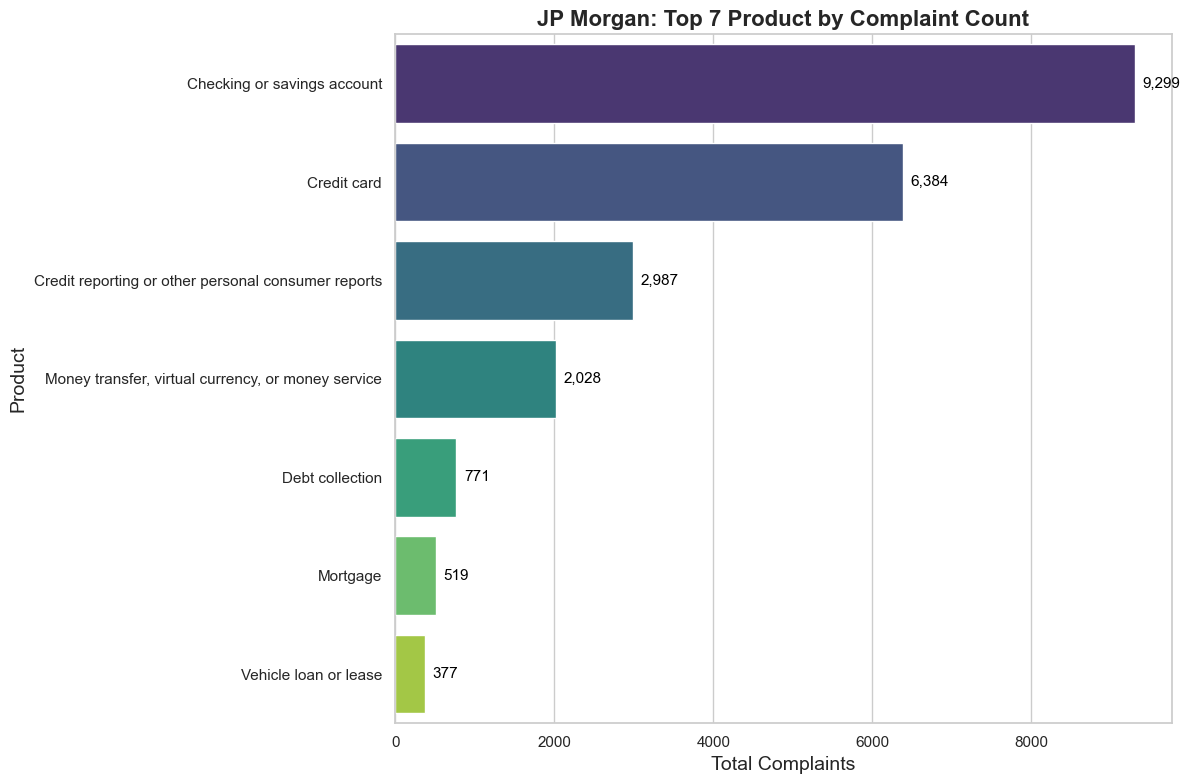

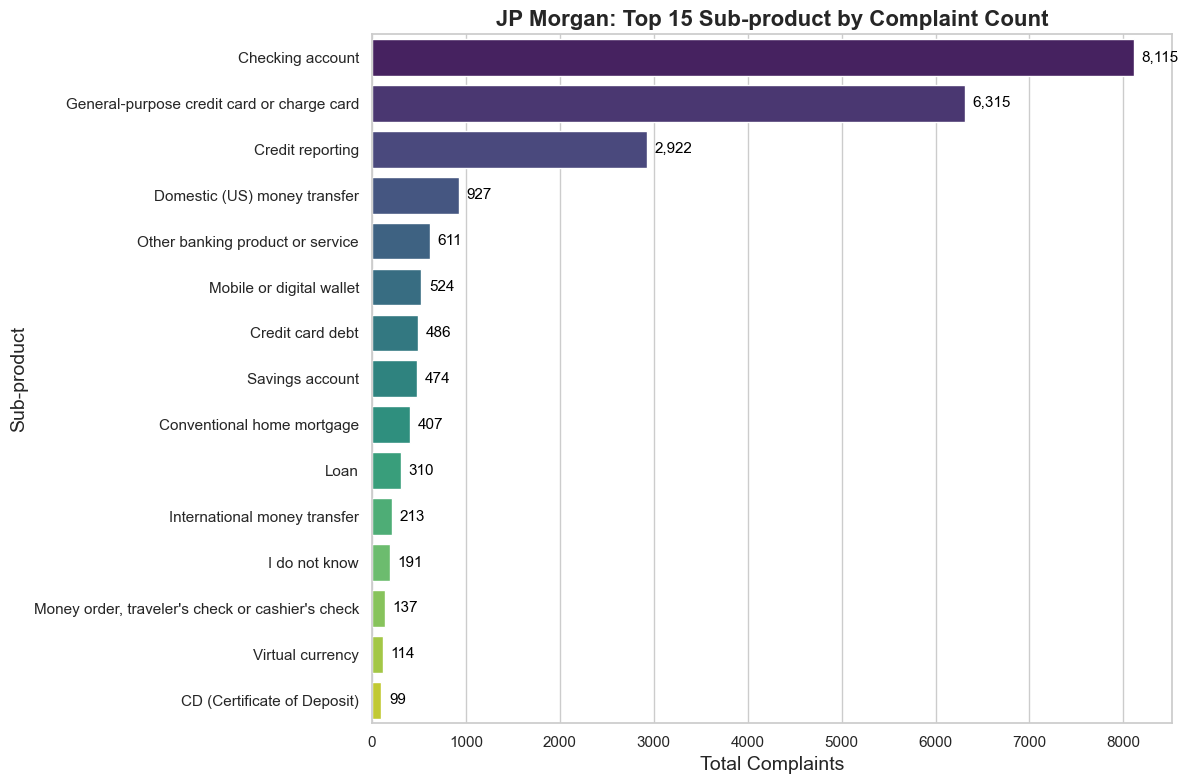

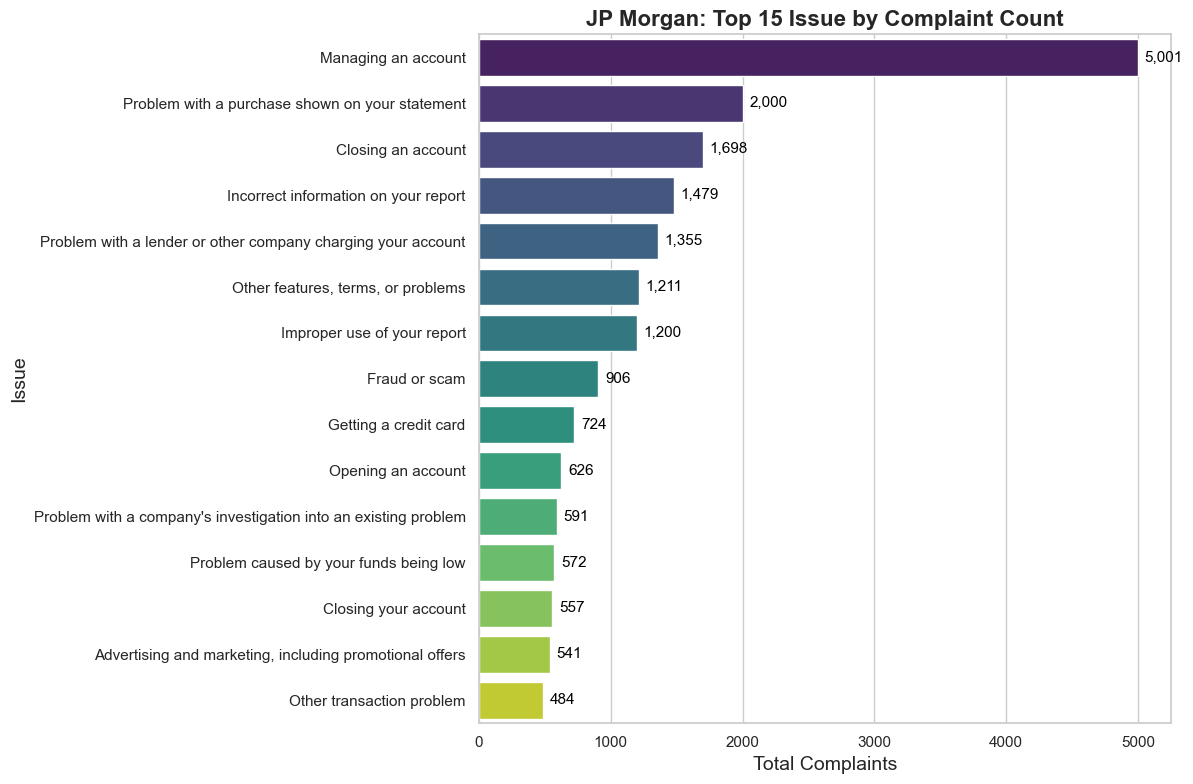

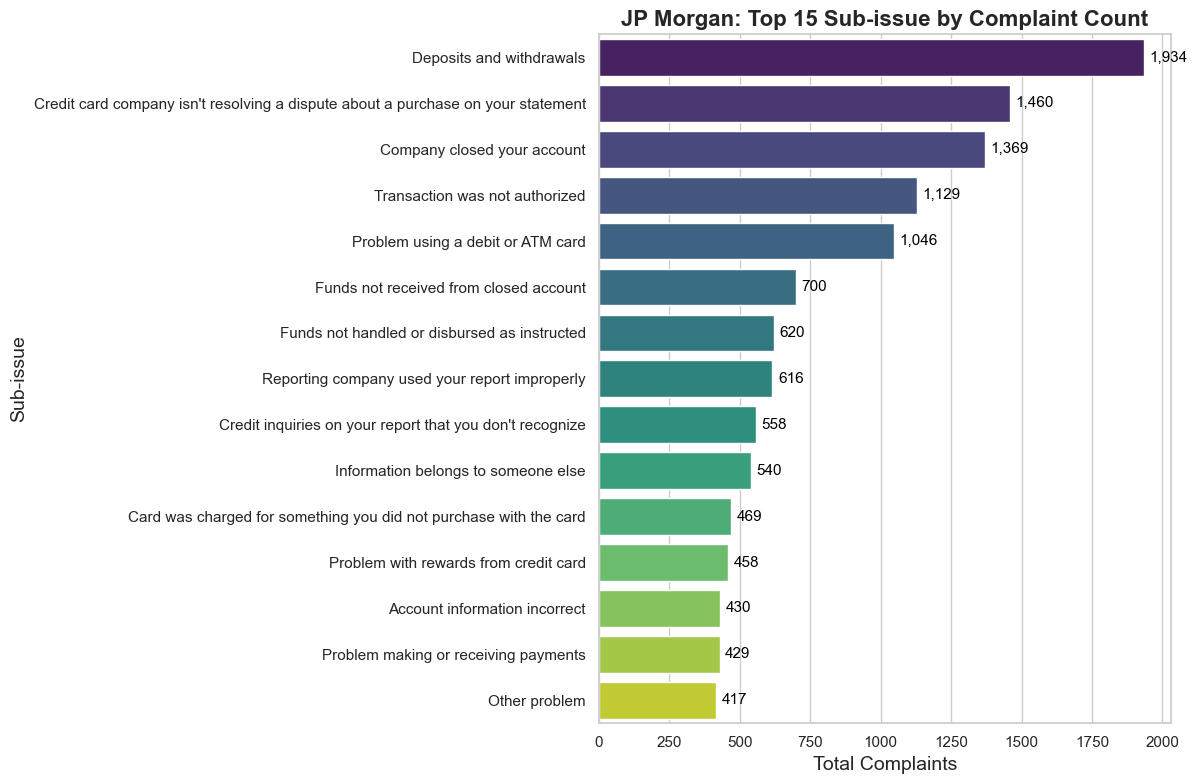

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style for nicer charts
sns.set_theme(style="whitegrid")

def plot_top_categories(df, column_name, top_n=15, title_prefix="JP Morgan:"):
    """
    Plots a horizontal bar chart for the top N categories of a given column in decreasing order.
    """
    # Count frequencies, sort in descending order, and take top N
    counts = df[column_name].value_counts().head(top_n)
    
    # Initialize the matplotlib figure
    plt.figure(figsize=(12, 8))
    
    # Plot using seaborn
    ax = sns.barplot(x=counts.values, y=counts.index, hue=counts.index, palette="viridis", legend=False)
    
    # Add titles and labels
    plt.title(f"{title_prefix} Top {len(counts)} {column_name} by Complaint Count", fontsize=16, fontweight='bold')
    plt.xlabel("Total Complaints", fontsize=14)
    plt.ylabel(column_name, fontsize=14)
    
    # Add the exact number next to each bar
    for i, v in enumerate(counts.values):
        ax.text(v + (counts.values.max() * 0.01), i, f"{v:,}", color='black', va='center', fontsize=11)
        
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# GENERATE THE PLOTS
# ---------------------------------------------------------

# 1. Product Plot
plot_top_categories(df, 'Product', top_n=15)

# 2. Sub-product Plot
plot_top_categories(df, 'Sub-product', top_n=15)

# 3. Issue Plot
plot_top_categories(df, 'Issue', top_n=15)

# 4. Sub-issue Plot
plot_top_categories(df, 'Sub-issue', top_n=15)